In [20]:
import pandas as pd

In [21]:
from google.colab import drive, files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
#curvas = pd.read_csv("/content/drive/MyDrive/CienciaDeDatos/Proyecto/spotify_charts_2017_2021.csv")

df_navidad = pd.read_csv("/content/drive/MyDrive/CienciaDeDatos/Proyecto/spotify_daily_panel_navidad.csv")

# Índices Navideños: borrador
## Introducción a la Ciencia de Datos
### Juan Pablo Rodríguez Villagrán

### 1. Procesado de los datos originales

In [16]:
# 2. Verificar columnas disponibles
print("Columnas disponibles:", curvas.columns.tolist())

Columnas disponibles: ['title', 'rank', 'date', 'artist', 'url', 'region', 'chart', 'trend', 'streams']


In [17]:
# 3. Convertir tipos de datos
curvas["date"] = pd.to_datetime(curvas["date"])
curvas["streams"] = pd.to_numeric(curvas["streams"], errors='coerce')

In [18]:
# 4. Crear df_core
df_core = curvas[["date", "region", "title", "artist", "rank", "streams", "chart"]].copy()
print(f"✅ df_core creado: {len(df_core):,} filas")

✅ df_core creado: 26,173,514 filas


In [19]:
# 5. Años de estudio
YEARS = list(range(2017, 2022))
print(f"🎯 Años analizados: {YEARS}")

🎯 Años analizados: [2017, 2018, 2019, 2020, 2021]


In [20]:
# 6. Asignar año de navidad
df_core["navidad_year"] = df_core["date"].dt.year
df_core.loc[df_core["date"].dt.month == 1, "navidad_year"] = df_core["date"].dt.year - 1

/tmp/ipython-input-1522135629.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2016 2016 2016 ... 2017 2017 2017]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df_core.loc[df_core["date"].dt.month == 1, "navidad_year"] = df_core["date"].dt.year - 1


In [21]:
# 7. Filtrar por años de navidad
df_core = df_core[df_core["navidad_year"].isin(YEARS)].copy()
print(f"✅ Después de filtrar por años navidad: {len(df_core):,} filas")

✅ Después de filtrar por años navidad: 25,809,088 filas


In [22]:
# 8. CORRECCIÓN PRINCIPAL: Filtrar fechas nov-ene
def crear_mascara_navidad(df):
    """Crea máscara para períodos de navidad: nov-dic (año actual) y ene (año siguiente)"""
    mascara = pd.Series(False, index=df.index)

    for year in YEARS:
        # Noviembre y Diciembre del año actual
        start_nov = pd.Timestamp(year, 11, 15)
        end_dic = pd.Timestamp(year, 12, 31)

        # Enero del año siguiente
        start_ene = pd.Timestamp(year + 1, 1, 1)
        end_ene = pd.Timestamp(year + 1, 1, 7)

        # Combinar máscaras
        periodo_navidad = (
            ((df["date"] >= start_nov) & (df["date"] <= end_dic)) |
            ((df["date"] >= start_ene) & (df["date"] <= end_ene))
        )

        mascara = mascara | periodo_navidad

    return mascara

# Aplicar la máscara corregida
mask_navidad = crear_mascara_navidad(df_core)
df_navidad = df_core[mask_navidad].copy()
print(f"✅ Después de filtrar por período navideño: {len(df_navidad):,} filas")

✅ Después de filtrar por período navideño: 3,582,358 filas


In [23]:
# 9. Verificar que tenemos datos
if len(df_navidad) == 0:
    print("⚠️  ALERTA: DataFrame vacío después del filtro navideño")
    print("Verificando años y meses disponibles:")
    print(df_core["date"].dt.year.value_counts().sort_index())
    print(df_core["date"].dt.month.value_counts().sort_index())
else:
    print("🎉 ¡Datos navideños encontrados!")

🎉 ¡Datos navideños encontrados!


In [24]:
df_navidad["region"].unique()

array(['Vietnam', 'Austria', 'Belgium', 'Chile', 'France', 'Germany',
       'Peru', 'Poland', 'Sweden', 'Argentina', 'Australia', 'Brazil',
       'Bolivia', 'Canada', 'Colombia', 'Costa Rica', 'Czech Republic',
       'Denmark', 'Dominican Republic', 'Ecuador', 'El Salvador',
       'Estonia', 'Finland', 'Global', 'Greece', 'Guatemala', 'Honduras',
       'Indonesia', 'Israel', 'Italy', 'Hong Kong', 'Hungary', 'Iceland',
       'Norway', 'Ireland', 'Japan', 'Latvia', 'Lithuania', 'Malaysia',
       'Mexico', 'Netherlands', 'New Zealand', 'Panama', 'Paraguay',
       'Philippines', 'Portugal', 'Romania', 'Singapore', 'Slovakia',
       'South Africa', 'Spain', 'Switzerland', 'Taiwan', 'Thailand',
       'Turkey', 'United Kingdom', 'Uruguay', 'United States', 'Bulgaria',
       'Luxembourg', 'Nicaragua', 'Egypt', 'India', 'Morocco',
       'Saudi Arabia', 'United Arab Emirates', 'Andorra', 'Russia',
       'Ukraine', 'South Korea'], dtype=object)

In [25]:
# 10. Filtrar regiones
REGIONES = ["Mexico", "United States", "United Kingdom", "Japan", "Argentina", "Canada", "Egypt", "South Korea", "Global"]
df_navidad = df_navidad[df_navidad["region"].isin(REGIONES)].copy()
print(f"✅ Después de filtrar regiones: {len(df_navidad):,} filas")

✅ Después de filtrar regiones: 469,812 filas


In [26]:
# 11. Verificación final
print("\n📊 RESUMEN FINAL:")
print(f"Regiones encontradas: {df_navidad['region'].unique()}")
print(f"Rango de fechas: {df_navidad['date'].min()} a {df_navidad['date'].max()}")
print(f"Años navidad presentes: {df_navidad['navidad_year'].unique()}")


📊 RESUMEN FINAL:
Regiones encontradas: ['Argentina' 'Canada' 'Global' 'Japan' 'Mexico' 'United Kingdom'
 'United States' 'Egypt' 'South Korea']
Rango de fechas: 2017-11-15 00:00:00 a 2021-12-31 00:00:00
Años navidad presentes: [2018 2019 2017 2020 2021]


In [27]:
# 12. Guardar y descargar
if len(df_navidad) > 0:
    df_navidad.to_csv('dataset_navidad.csv', index=False)
    files.download('dataset_navidad.csv')
    print("📥 Archivo descargado: dataset_navidad.csv")
else:
    print("❌ No hay datos para descargar")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Archivo descargado: dataset_navidad.csv


### 2. Construcción del índice
A partir de este punto, sólo trabajar los datos cortos..., el otro archivo pesa DEMASIADO.

In [23]:
# Agrupamos por región, canción y año navideño
group_cols = ["region", "title", "artist", "navidad_year"]

agg = (
    df_navidad
    .groupby(group_cols)
    .agg(
        max_streams=("streams", "max"),
        best_rank=("rank", "min"),
        days_in_chart=("date", "nunique"),
    )
    .reset_index()
)

#agg.head()


In [24]:
# S_{p,t}: suma de max_streams en cada región y año navidad
total_by_year = (
    agg
    .groupby(["region", "navidad_year"])["max_streams"]
    .sum()
    .rename("total_max_streams")
    .reset_index()
)

agg2 = agg.merge(total_by_year, on=["region", "navidad_year"], how="left")
agg2["share"] = agg2["max_streams"] / agg2["total_max_streams"]

#agg2.head()


In [25]:
# Resumen por (region, title, artist)
group_song = ["region", "title", "artist"]

summary = (
    agg2
    .groupby(group_song)
    .agg(
        years_present=("navidad_year", "nunique"),
        mean_share=("share", "mean"),
        top5_hits=("best_rank", lambda x: (x <= 5).sum()),
        mean_best_rank=("best_rank", "mean"),
    )
    .reset_index()
)

summary.head()


,region,title,artist,years_present,mean_share,top5_hits,mean_best_rank
0,Argentina,#Natural,"Paty Cantú, Juhn",1,0.003398,0,22.0
1,Argentina,#Ysya2020 Vol. 5 - Silbando,"YSY A, CLUB HATS",1,0.000938,0,43.0
2,Argentina,#Ysya2020 Vol. 6 - Un Flow de Infarto,"YSY A, Bizarrap",1,0.001041,0,22.0
3,Argentina,+ (MÁS),"Aitana, Cali Y El Dandee",1,0.000842,0,190.0
4,Argentina,+Linda,Dalex,1,0.001795,0,67.0


In [26]:
def zscore_by_region(df, col, region_col="region"):
    """
    Calcula z-score de 'col' dentro de cada región.
    """
    return df.groupby(region_col)[col].transform(
        lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1.0)
    )

In [27]:
summary["z_years"] = zscore_by_region(summary, "years_present")
summary["z_mean_share"] = zscore_by_region(summary, "mean_share")

# Para top5_hits puede haber muchas ceros; aún así estandarizamos
summary["z_top5"] = zscore_by_region(summary, "top5_hits")

# Índice de navideñidad basado sólo en charts
summary["xmas_score_charts"] = (
    summary["z_years"] +
    summary["z_mean_share"] +
    0.5 * summary["z_top5"]
)

In [28]:
# Ranking por región
summary_sorted = (
    summary
    .sort_values(["region", "xmas_score_charts"], ascending=[True, False])
    .reset_index(drop=True)
)

summary_sorted.head(20)

,region,title,artist,years_present,mean_share,top5_hits,mean_best_rank,z_years,z_mean_share,z_top5,xmas_score_charts
0,Argentina,Bar,"TINI, L-Gante",1,0.022004,1,1.000000,-0.308162,8.478452,3.911421,10.126000
1,Argentina,Corazón,"Maluma, Nego do Borel",1,0.021790,1,1.000000,-0.308162,8.384694,3.911421,10.032242
2,Argentina,"Taki Taki (with Selena Gomez, Ozuna & Cardi B)",DJ Snake,1,0.018423,1,1.000000,-0.308162,6.912402,3.911421,8.559950
3,Argentina,Leña para el Carbón,DJ Alex,1,0.017974,1,2.000000,-0.308162,6.715920,3.911421,8.363468
4,Argentina,Me Vas a Extrañar - En Vivo,"Damas Gratis, Viru Kumbieron",4,0.007756,1,36.500000,3.982620,2.247893,3.911421,8.186223
5,Argentina,"Tiago PZK: Bzrp Music Sessions, Vol. 48","Bizarrap, Tiago PZK",1,0.017101,1,1.000000,-0.308162,6.334466,3.911421,7.982014
6,Argentina,Adan y Eva,Paulo Londra,3,0.010101,1,68.000000,2.552359,3.273461,3.911421,7.781531
7,Argentina,Salimo de Noche,"Tiago PZK, Trueno",1,0.015903,1,2.000000,-0.308162,5.810373,3.911421,7.457921
8,Argentina,L-Gante Rkt,"Papu DJ, L-Gante",1,0.015310,1,1.000000,-0.308162,5.551067,3.911421,7.198615
9,Argentina,Criminal,"Natti Natasha, Ozuna",2,0.011783,1,30.000000,1.122098,4.008738,3.911421,7.086546


In [29]:
summary_sorted[summary_sorted["region"] == "Japan"].head(10)

,region,title,artist,years_present,mean_share,top5_hits,mean_best_rank,z_years,z_mean_share,z_top5,xmas_score_charts
8396,Japan,All I Want for Christmas Is You,Mariah Carey,5,0.011241,3,16.600000,6.070599,4.431124,9.894643,15.449044
8397,Japan,Last Christmas,Wham!,5,0.008091,2,35.800000,6.070599,2.841771,6.503126,12.163932
8398,Japan,夜に駆ける,YOASOBI,3,0.013036,2,4.333333,2.862423,5.336987,6.503126,11.450973
8399,Japan,Dynamite,BTS,2,0.015268,2,3.000000,1.258335,6.462977,6.503126,10.972875
8400,Japan,Fairytale of New York (feat. Kirsty MacColl),The Pogues,5,0.002157,2,7.600000,6.070599,-0.152336,6.503126,9.169826
8401,Japan,打上花火,"DAOKO, Kenshi Yonezu",4,0.005192,2,36.750000,4.466511,1.379039,6.503126,9.097113
8402,Japan,Santa Tell Me,Ariana Grande,4,0.008366,1,10.000000,4.466511,2.980458,3.111608,9.002773
8403,Japan,Pretender,Official HIGE DANdism,3,0.011241,1,14.000000,2.862423,4.431228,3.111608,8.849455
8404,Japan,Shape of You,Ed Sheeran,5,0.004832,1,49.800000,6.070599,1.197326,3.111608,8.823729
8405,Japan,Wherever you are,ONE OK ROCK,5,0.003974,1,46.800000,6.070599,0.764321,3.111608,8.390724


In [30]:
# Mostrar las top 5 canciones navideñas por región
tabla_top = (
    summary_sorted
    .groupby("region")
    .head(5)
    .reset_index(drop=True)
    [["region", "title", "artist", "xmas_score_charts"]]
)

tabla_top

,region,title,artist,xmas_score_charts
0,Argentina,Bar,"TINI, L-Gante",10.126000
1,Argentina,Corazón,"Maluma, Nego do Borel",10.032242
2,Argentina,"Taki Taki (with Selena Gomez, Ozuna & Cardi B)",DJ Snake,8.559950
3,Argentina,Leña para el Carbón,DJ Alex,8.363468
4,Argentina,Me Vas a Extrañar - En Vivo,"Damas Gratis, Viru Kumbieron",8.186223
5,Canada,All I Want for Christmas Is You,Mariah Carey,18.608673
6,Canada,Last Christmas,Wham!,16.920812
7,Canada,It's the Most Wonderful Time of the Year,Andy Williams,15.297696
8,Canada,It's Beginning to Look a Lot like Christmas,Michael Bublé,15.017399
9,Canada,Rockin' Around The Christmas Tree,Brenda Lee,14.952756


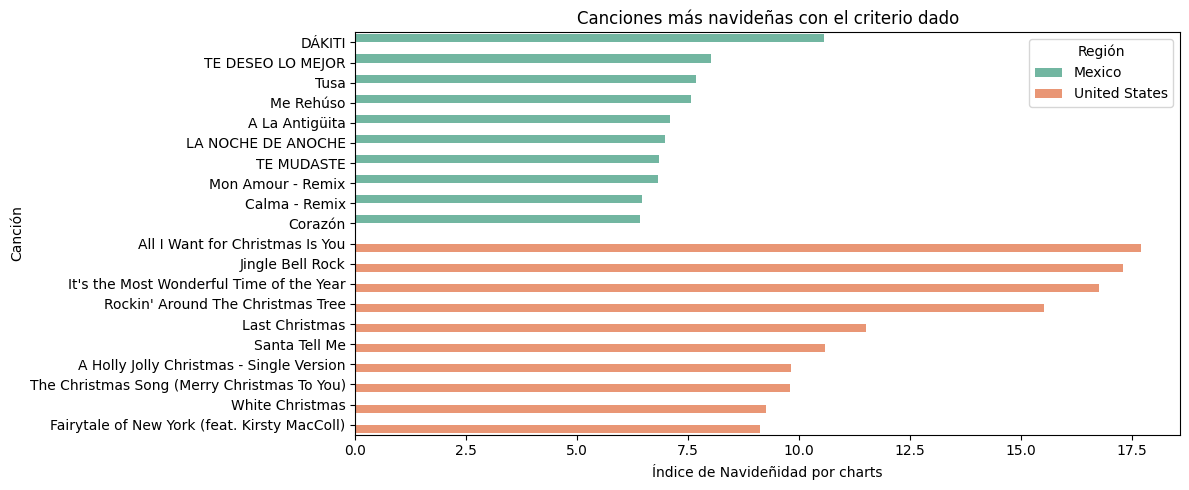

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Elegimos dos regiones
regiones_visualizar = ["Mexico", "United States"]

top_por_region = (
    summary_sorted
    [summary_sorted["region"].isin(regiones_visualizar)]
    .groupby("region")
    .head(10)    # top 10 por claridad
)

plt.figure(figsize=(12,5))
sns.barplot(
    data=top_por_region,
    x="xmas_score_charts",
    y="title",
    hue="region",
    dodge=True,
    palette="Set2"
)
plt.xlabel("Índice de Navideñidad por charts")
plt.ylabel("Canción")
plt.title("Canciones más navideñas con el criterio dado")
plt.legend(title="Región")
plt.tight_layout()
plt.savefig("MexvsUK.pdf")
plt.show()

/tmp/ipython-input-1499833094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


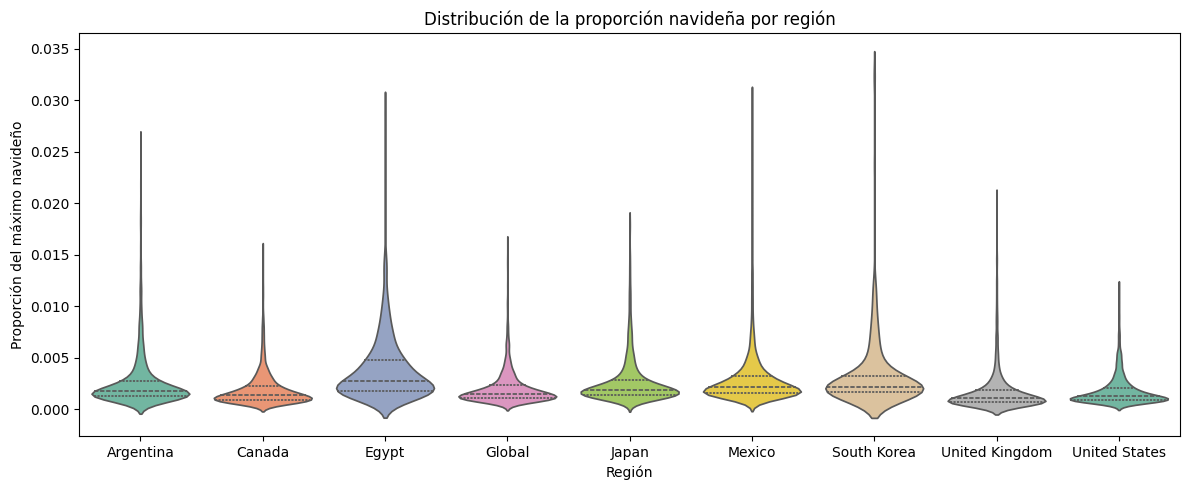

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.violinplot(
    data=agg2,
    x="region",
    y="share",
    inner="quartile",
    palette="Set2"
)

plt.title("Distribución de la proporción navideña por región")
plt.xlabel("Región")
plt.ylabel("Proporción del máximo navideño")
plt.tight_layout()
plt.savefig("violin.pdf")
plt.show()

In [100]:
song_scores = mat.copy()  # song_id × region
regions = song_scores.columns

# 1) Globalidad
presence = (song_scores > 0).sum(axis=1)  # en cuántos países aparece
G = presence / len(regions)

song_global_stats = pd.DataFrame({
    "G": G,
})

song_global_stats.tail()

,G
song_id,
鱗(うろこ) — Motohiro Hata,0.111111
黄色 — back number,0.111111
사이렌 — HOMIES,0.000000
"우산 (feat. 윤하) — Epik High, Younha",0.000000
친구 — BTS,0.000000


In [102]:
topG = (
    song_global_stats
    .sort_values("G", ascending=False)
    .head(20)          # cambia 20 por el top que quieras
)
#topG

# df_songs o summary_sorted deben tener song_id, title, artist
song_meta = (
    summary_sorted[["song_id", "title", "artist"]]
    .drop_duplicates()
    .set_index("song_id")
)

topG_pretty = topG.join(song_meta, how="left")
topG_pretty[["title", "artist", "G"]]

,title,artist,G
song_id,,,
abcdefu — GAYLE,abcdefu,GAYLE,1.000000
Blinding Lights — The Weeknd,Blinding Lights,The Weeknd,0.888889
Someone You Loved — Lewis Capaldi,Someone You Loved,Lewis Capaldi,0.888889
STAY (with Justin Bieber) — The Kid LAROI,STAY (with Justin Bieber),The Kid LAROI,0.888889
SAD GIRLZ LUV MONEY Remix (feat. Kali Uchis and Moliy) — Amaarae,SAD GIRLZ LUV MONEY Remix (feat. Kali Uchis an...,Amaarae,0.888889
All I Want for Christmas Is You — Mariah Carey,All I Want for Christmas Is You,Mariah Carey,0.888889
Santa Tell Me — Ariana Grande,Santa Tell Me,Ariana Grande,0.888889
Dance Monkey — Tones And I,Dance Monkey,Tones And I,0.888889
"Señorita — Shawn Mendes, Camila Cabello",Señorita,"Shawn Mendes, Camila Cabello",0.777778


#### La parte de clustering

In [103]:
df_songs = summary_sorted.copy()
df_songs["song_id"] = df_songs["title"] + " — " + df_songs["artist"]

In [104]:

# matriz ancha: filas = song_id, columnas = región, valores = xmas_score_charts
mat = (
    df_songs
    .pivot_table(
        index="song_id",
        columns="region",
        values="xmas_score_charts",
        aggfunc="mean"   # por si la misma canción apareció varias veces
    )
    .fillna(0.0)
)

#mat.head()


In [126]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = mat.values   # matriz numérica (n_songs × n_regions)

# Escalamos por columna (región) para que cada país tenga contribución comparable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elegimos, por ejemplo, 3 o 4 clusters para empezar
k = 2
kmeans = KMeans(n_clusters=k, random_state=1008)
clusters = kmeans.fit_predict(X_scaled)

mat_clusters = mat.copy()
mat_clusters["cluster"] = clusters
#mat_clusters.head()

In [127]:
# Volver a juntar con el nombre y artista
song_meta = (
    df_songs[["song_id", "title", "artist"]]
    .drop_duplicates()
    .set_index("song_id")
)

songs_clustered = mat_clusters.join(song_meta, how="left")
#songs_clustered.head()


In [128]:
for c in range(k):
    print(f"\n=== Cluster {c} ===")
    subset = songs_clustered[songs_clustered["cluster"] == c]
    print("Tamaño del cluster:", len(subset))

    # Canciones más representativas (ordenar por suma total de puntuaciones)
    subset = subset.assign(total_score=subset[mat.columns].sum(axis=1))
    display(
        subset.sort_values("total_score", ascending=False)[
            ["title", "artist", "total_score"]
        ].head(10)
    )



=== Cluster 0 ===
Tamaño del cluster: 6353


,title,artist,total_score
song_id,,,
"DÁKITI — Bad Bunny, Jhay Cortez",DÁKITI,"Bad Bunny, Jhay Cortez",23.110798
"Taki Taki (with Selena Gomez, Ozuna & Cardi B) — DJ Snake","Taki Taki (with Selena Gomez, Ozuna & Cardi B)",DJ Snake,19.774545
Dynamite — BTS,Dynamite,BTS,19.178810
"Calma - Remix — Pedro Capó, Farruko",Calma - Remix,"Pedro Capó, Farruko",16.714531
"Tusa — KAROL G, Nicki Minaj",Tusa,"KAROL G, Nicki Minaj",15.120117
Adan y Eva — Paulo Londra,Adan y Eva,Paulo Londra,15.035133
"Échame La Culpa — Luis Fonsi, Demi Lovato",Échame La Culpa,"Luis Fonsi, Demi Lovato",14.288698
"Corazón — Maluma, Nego do Borel",Corazón,"Maluma, Nego do Borel",14.227202
MIA (feat. Drake) — Bad Bunny,MIA (feat. Drake),Bad Bunny,13.955347



=== Cluster 1 ===
Tamaño del cluster: 183


,title,artist,total_score
song_id,,,
All I Want for Christmas Is You — Mariah Carey,All I Want for Christmas Is You,Mariah Carey,101.905318
Last Christmas — Wham!,Last Christmas,Wham!,86.465667
Rockin' Around The Christmas Tree — Brenda Lee,Rockin' Around The Christmas Tree,Brenda Lee,64.875670
Jingle Bell Rock — Bobby Helms,Jingle Bell Rock,Bobby Helms,64.642084
It's Beginning to Look a Lot like Christmas — Michael Bublé,It's Beginning to Look a Lot like Christmas,Michael Bublé,63.786162
It's the Most Wonderful Time of the Year — Andy Williams,It's the Most Wonderful Time of the Year,Andy Williams,57.857942
Santa Tell Me — Ariana Grande,Santa Tell Me,Ariana Grande,56.570161
Fairytale of New York (feat. Kirsty MacColl) — The Pogues,Fairytale of New York (feat. Kirsty MacColl),The Pogues,53.157256
Easy On Me — Adele,Easy On Me,Adele,47.635104


In [129]:
mat_country = mat.transpose()  # filas = región, columnas = song_id
mat_country.head()

song_id,#302 — Ken Hirai,"#Natural — Paty Cantú, Juhn","#Ysya2020 Vol. 5 - Silbando — YSY A, CLUB HATS","#Ysya2020 Vol. 6 - Un Flow de Infarto — YSY A, Bizarrap",$€ Freestyle — Sfera Ebbasta,'Til You Can't — Cody Johnson,"'Till I Collapse — Eminem, Nate Dogg","'Zat You, Santa Claus? - Single Version — Louis Armstrong, The Commanders",(Sittin' On) the Dock of the Bay — Otis Redding,(There's No Place Like) Home for the Holidays - 1959 Version — Perry Como,...,飾りじゃないのよ 涙は — King Gnu,香水 — Eito,馬と鹿 — Kenshi Yonezu,高嶺の花子さん — back number,魔法の絨毯 — Takaya Kawasaki,鱗(うろこ) — Motohiro Hata,黄色 — back number,사이렌 — HOMIES,"우산 (feat. 윤하) — Epik High, Younha",친구 — BTS
region,,,,,,,,,,,,,,,,,,,,,
Argentina,0.000000,-0.093869,-1.169647,-1.124688,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Canada,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.388213,0.0,0.0,-0.378618,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Egypt,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Global,0.000000,0.000000,0.000000,0.000000,-0.990589,0.0,-1.110178,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Japan,-0.837474,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,-0.240839,3.138299,0.491744,3.631708,3.947679,3.074578,2.560135,0.0,0.0,0.0


In [138]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

Y = mat_country.values
scaler_c = StandardScaler()
Y_scaled = scaler_c.fit_transform(Y)

# Clustering jerárquico, por ejemplo 3 grupos de países
clust_countries = AgglomerativeClustering(n_clusters=2, linkage="ward")
country_labels = clust_countries.fit_predict(Y_scaled)

country_clusters = mat_country.copy()
country_clusters["cluster"] = country_labels
country_clusters

song_id,#302 — Ken Hirai,"#Natural — Paty Cantú, Juhn","#Ysya2020 Vol. 5 - Silbando — YSY A, CLUB HATS","#Ysya2020 Vol. 6 - Un Flow de Infarto — YSY A, Bizarrap",$€ Freestyle — Sfera Ebbasta,'Til You Can't — Cody Johnson,"'Till I Collapse — Eminem, Nate Dogg","'Zat You, Santa Claus? - Single Version — Louis Armstrong, The Commanders",(Sittin' On) the Dock of the Bay — Otis Redding,(There's No Place Like) Home for the Holidays - 1959 Version — Perry Como,...,香水 — Eito,馬と鹿 — Kenshi Yonezu,高嶺の花子さん — back number,魔法の絨毯 — Takaya Kawasaki,鱗(うろこ) — Motohiro Hata,黄色 — back number,사이렌 — HOMIES,"우산 (feat. 윤하) — Epik High, Younha",친구 — BTS,cluster
region,,,,,,,,,,,,,,,,,,,,,
Argentina,0.000000,-0.093869,-1.169647,-1.124688,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
Canada,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.388213,0.000000,0.00000,-0.378618,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
Egypt,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
Global,0.000000,0.000000,0.000000,0.000000,-0.990589,0.000000,-1.110178,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
Japan,-0.837474,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,3.138299,0.491744,3.631708,3.947679,3.074578,2.560135,0.000000,0.000000,0.000000,0
Mexico,0.000000,0.066447,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
South Korea,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.513384,-0.620084,-0.583793,0
United Kingdom,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.081852,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
United States,0.000000,0.000000,0.000000,0.000000,0.000000,-1.323144,-1.047660,-0.383598,-1.28897,1.146922,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1


In [140]:
country_clusters[["cluster"]]


song_id,cluster
region,
Argentina,0
Canada,1
Egypt,0
Global,1
Japan,0
Mexico,0
South Korea,0
United Kingdom,1
United States,1


In [132]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Matriz numérica
X = mat.values

# 1) Escalado por columna (país)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2) PCA a 2 dimensiones para visualizar
pca_songs = PCA(n_components=2, random_state=1008)
X_pca = pca_songs.fit_transform(X_scaled)

# 3) KMeans con, por ejemplo, 4 clusters de canciones
k_songs = 2
kmeans_songs = KMeans(n_clusters=k_songs, random_state=1008, n_init="auto")
song_labels = kmeans_songs.fit_predict(X_pca)

# DataFrame para plotear
df_songs_pca = pd.DataFrame({
    "song_id": mat.index,
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": song_labels,
})

# Recuperar título y artista
song_meta = (
    summary_sorted[["song_id", "title", "artist"]]
    .drop_duplicates()
    .set_index("song_id")
)

df_songs_pca = df_songs_pca.join(song_meta, on="song_id")
df_songs_pca.head()


,song_id,PC1,PC2,cluster,title,artist
0,#302 — Ken Hirai,-0.268682,-0.065700,0,#302,Ken Hirai
1,"#Natural — Paty Cantú, Juhn",-0.083802,-0.060234,0,#Natural,"Paty Cantú, Juhn"
2,"#Ysya2020 Vol. 5 - Silbando — YSY A, CLUB HATS",-0.156504,-1.011730,0,#Ysya2020 Vol. 5 - Silbando,"YSY A, CLUB HATS"
3,"#Ysya2020 Vol. 6 - Un Flow de Infarto — YSY A,...",-0.153849,-0.974447,0,#Ysya2020 Vol. 6 - Un Flow de Infarto,"YSY A, Bizarrap"
4,$€ Freestyle — Sfera Ebbasta,-0.561350,-0.048616,0,$€ Freestyle,Sfera Ebbasta


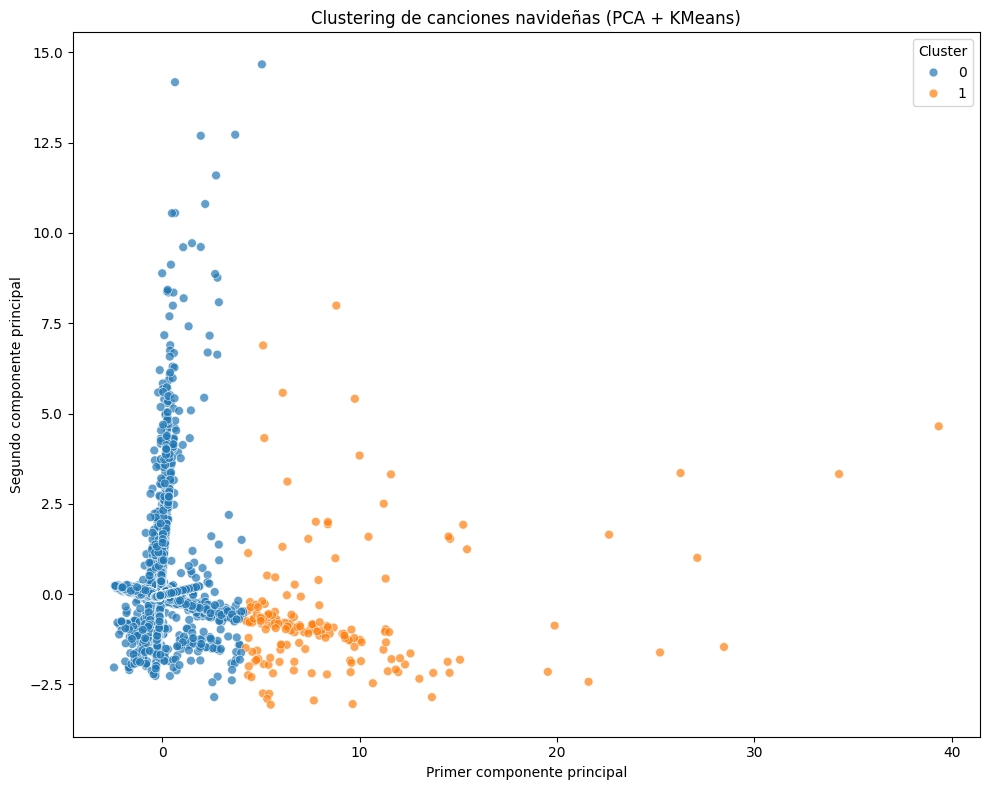

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_songs_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",

    alpha=0.7,
    s=40
)

plt.title("Clustering de canciones navideñas (PCA + KMeans)")
plt.xlabel("Primer componente principal")
plt.ylabel("Segundo componente principal")
plt.legend(title="Cluster", loc="best")
plt.tight_layout()
plt.show()

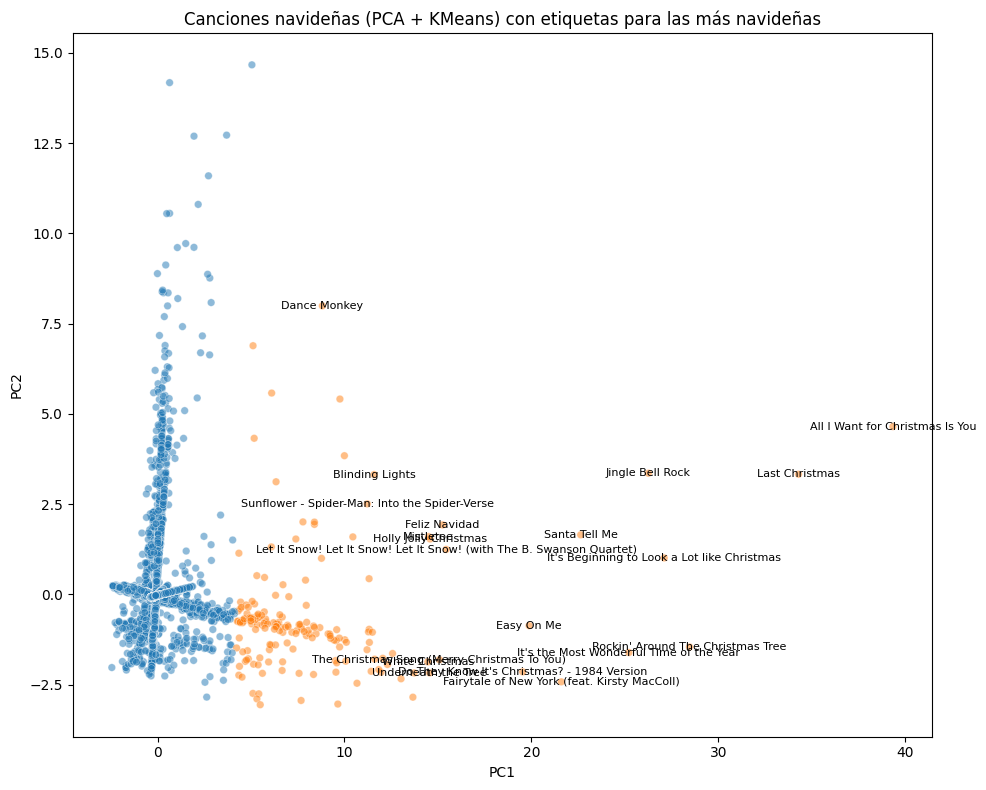

In [134]:
# Suma de puntuaciones sobre todas las regiones, para cada canción
song_total_score = mat.sum(axis=1).rename("total_score")
df_songs_pca = df_songs_pca.join(song_total_score, on="song_id")

# Tomar las 20 más navideñas globalmente
top_to_label = (
    df_songs_pca
    .sort_values("total_score", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_songs_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.5,
    s=30,
    legend=False
)

# Añadir etiquetas de texto para las top
for _, row in top_to_label.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        row["title"],
        fontsize=8,
        ha="center",
        va="center"
    )

plt.title("Canciones navideñas (PCA + KMeans) con etiquetas para las más navideñas")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("PCA2K2means.pdf")
plt.show()